In [1]:
library(TCGAbiolinks)
library(SummarizedExperiment)
library(ggplot2)
library(ggpubr)
library(pROC)
library(dplyr)
library(tidyr)
library(GSVA)
library(dplyr)
library(gtsummary)

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: 'MatrixGenerics'


The following objects are masked from 'package:matrixStats':

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles, rowRanges, rowRanks,
    rowSdDiffs, rowSds, rowSums2, ro

In [ ]:
# if (!requireNamespace("BiocManager", quietly = TRUE)) {
#     install.packages("BiocManager")
# }

# # سپس پکیج GSVA را از طریق BiocManager نصب کنید
# BiocManager::install("GSVA")
# install.packages("gtsummary")
# install.packages("dplyr")
# install.packages("dplyr")
# install.packages("rlang")





: 

In [ ]:
# تنظیم درخواست برای دریافت داده های RNA-Seq سرطان ریه (LUAD به عنوان مثال)
# توجه: برای LUSC نیز باید همین مسیر تکرار شده و داده ها ادغام شوند.
query_TCGA <- GDCquery(
  project = "TCGA-LUAD",
  data.category = "Transcriptome Profiling",
  data.type = "Gene Expression Quantification",
  workflow.type = "STAR - Counts"
)

# دانلود داده ها (این مرحله ممکن است زمان بر باشد)
GDCdownload(query_TCGA)
tcga_data <- GDCprepare(query_TCGA)

# استخراج داده های TPM و اطلاعات بالینی
tpm_matrix <- assay(tcga_data, "tpm_unstrand")
clinical_df <- as.data.frame(colData(tcga_data))

# استخراج اطلاعات مربوط به ژن ها (متادیتا)
gene_info <- rowData(tcga_data)

# پیدا کردن نام دقیق ردیف (Row Name) برای ژن ZBTB16 با استفاده از نام استاندارد آن
zbtb16_row_name <- rownames(tcga_data)[which(gene_info$gene_name == "ZBTB16")]

# اگر به هر دلیلی gene_name کار نکرد، میتوانید از دستور زیر استفاده کنید:
# zbtb16_row_name <- rownames(tpm_matrix)[grepl("ENSG00000109906", rownames(tpm_matrix))]

# استخراج مقادیر بیان ژن بر اساس ردیف پیدا شده
zbtb16_expr <- tpm_matrix[zbtb16_row_name, ]

# ایجاد یک دیتافریم مرتب برای رسم نمودارها
df_expr <- data.frame(
  Sample = colnames(tpm_matrix),
  Expression = as.numeric(zbtb16_expr),
  # تشخیص بافت نرمال و تومور بر اساس کد نمونه در TCGA (کدهای کمتر از 10 تومور هستند)
  Group = ifelse(as.numeric(substr(colnames(tpm_matrix), 14, 15)) < 10, "Tumor", "Normal")
)

# تبدیل داده ها به Log2(TPM + 1) برای نرمال سازی توزیع
df_expr$Log2TPM <- log2(df_expr$Expression + 1)

# بررسی کوتاه برای اطمینان از صحت استخراج داده ها
head(df_expr)



--------------------------------------

o GDCquery: Searching in GDC database

--------------------------------------

Genome of reference: hg38

--------------------------------------------

oo Accessing GDC. This might take a while...

--------------------------------------------

ooo Project: TCGA-LUAD

--------------------

oo Filtering results

--------------------

ooo By data.type

ooo By workflow.type

----------------

oo Checking data

----------------

ooo Checking if there are duplicated cases

ooo Checking if there are results for the query

-------------------

o Preparing output

-------------------


Of the 601 files for download 601 already exist.

All samples have been already downloaded



|====================================================|100%                      Completed after 38 s 


Starting to add information to samples

 => Add clinical information to samples

 => Adding TCGA molecular information from marker papers

 => Information will have prefix 'paper_' 

luad subtype information from:doi:10.1038/nature13385

Available assays in SummarizedExperiment : 
  => unstranded
  => stranded_first
  => stranded_second
  => tpm_unstrand
  => fpkm_unstrand
  => fpkm_uq_unstrand



,Sample,Expression,Group,Log2TPM
,<chr>,<dbl>,<chr>,<dbl>
1,TCGA-44-2655-11A-01R-1758-07,32.6906,Normal,5.0742742
2,TCGA-86-8358-01A-11R-2326-07,1.1347,Tumor,1.0940333
3,TCGA-86-A4D0-01A-11R-A24H-07,0.4207,Tumor,0.5066019
4,TCGA-73-4666-01A-01R-1206-07,2.5952,Tumor,1.8460720
5,TCGA-NJ-A4YQ-01A-11R-A262-07,0.5227,Tumor,0.6066317
6,TCGA-86-7714-01A-12R-2170-07,77.3033,Tumor,6.2910012


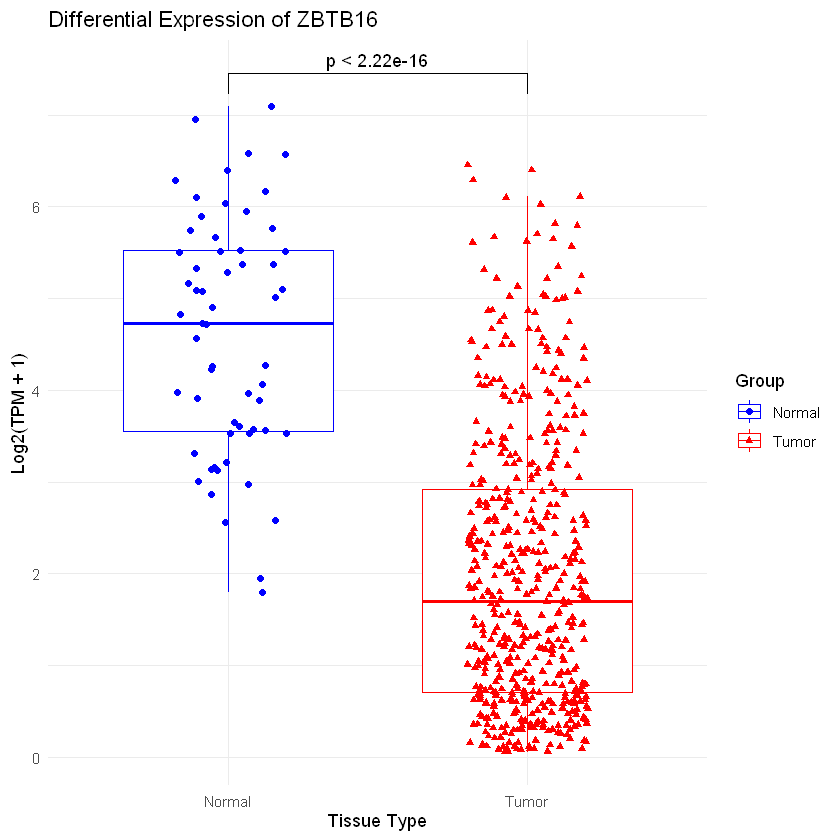

In [3]:
fig_5c <- ggboxplot(df_expr, x = "Group", y = "Log2TPM",
                    color = "Group", palette = c("blue", "red"),
                    add = "jitter", shape = "Group") +
  stat_compare_means(method = "wilcox.test", comparisons = list(c("Normal", "Tumor"))) +
  labs(title = "Differential Expression of ZBTB16",
       x = "Tissue Type",
       y = "Log2(TPM + 1)") +
  theme_minimal()

print(fig_5c)

Setting levels: control = 0, case = 1

Setting direction: controls > cases

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the pROC package.
  Please report the issue at <https://github.com/xrobin/pROC/issues>."
Warning message in geom_segment(aes(x = 1, xend = 0, y = 0, yend = 1), color = "black", :
"All aesthetics have length 1, but the data has 599 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing
  a single row."


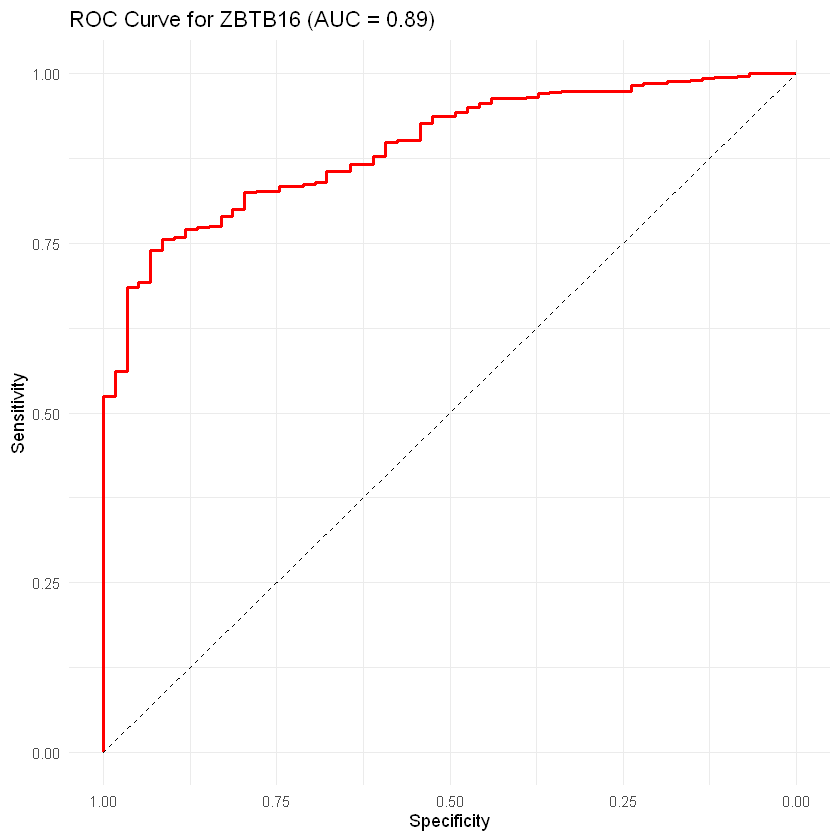

In [4]:
df_expr$Outcome <- ifelse(df_expr$Group == "Tumor", 1, 0)

# محاسبه ROC
roc_obj <- roc(df_expr$Outcome, df_expr$Log2TPM)

# استخراج مقادیر حساسیت و ویژگی برای گزارش
auc_val <- round(auc(roc_obj), 2)

# رسم منحنی ROC
fig_5e <- ggroc(roc_obj, colour = "red", size = 1) +
  theme_minimal() +
  ggtitle(paste0("ROC Curve for ZBTB16 (AUC = ", auc_val, ")")) +
  geom_segment(aes(x = 1, xend = 0, y = 0, yend = 1), color="black", linetype="dashed") +
  labs(x = "Specificity", y = "Sensitivity")

print(fig_5e)

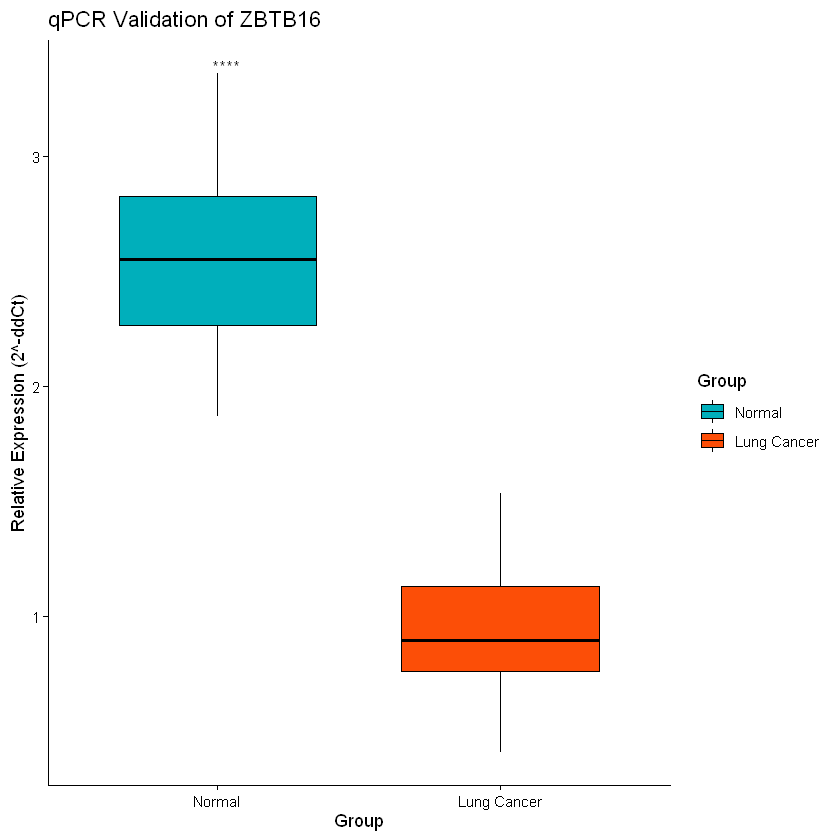

In [5]:
# ساخت داده فرضی برای qPCR
set.seed(123)
qpcr_data <- data.frame(
  Group = rep(c("Normal", "Lung Cancer"), each = 12),
  Relative_Expression = c(rnorm(12, mean = 2.5, sd = 0.5), rnorm(12, mean = 1.0, sd = 0.3))
)

# رسم نمودار میله ای یا جعبه ای برای qPCR
fig_5d <- ggboxplot(qpcr_data, x = "Group", y = "Relative_Expression",
                    fill = "Group", palette = c("#00AFBB", "#FC4E07")) +
  stat_compare_means(method = "t.test", label = "p.signif") + # بر اساس t-test استفاده شده در مقاله
  labs(title = "qPCR Validation of ZBTB16",
       x = "Group",
       y = "Relative Expression (2^-ddCt)") +
  theme_classic()

print(fig_5d)


In [ ]:

table2_data <- tumor_data %>%
  mutate(
    # گروه بندی Pathologic T stage
    T_stage = case_when(
      grepl("T1", pathologic_T) ~ "T1",
      grepl("T2", pathologic_T) ~ "T2",
      grepl("T3|T4", pathologic_T) ~ "T3&T4",
      TRUE ~ NA_character_
    ),
    
    # گروه بندی Pathologic N stage
    N_stage = case_when(
      grepl("N0", pathologic_N) ~ "N0",
      grepl("N1", pathologic_N) ~ "N1",
      grepl("N2|N3", pathologic_N) ~ "N2&N3",
      TRUE ~ NA_character_
    ),
    
    # گروه بندی Age
    Age_group = case_when(
      age <= 65 ~ "<=65",
      age > 65 ~ ">65",
      TRUE ~ NA_character_
    ),
    
    # گروه بندی Pathologic stage
    # توجه: داده های TCGA دارای Stage IA و Stage IB و غیره هستند که باید ادغام شوند
    Stage = case_when(
      grepl("Stage I$|Stage IA|Stage IB", pathologic_stage) ~ "Stage I",
      grepl("Stage II$|Stage IIA|Stage IIB", pathologic_stage) ~ "Stage II",
      grepl("Stage III|Stage IV", pathologic_stage) ~ "Stage III&Stage IV",
      TRUE ~ NA_character_
    ),
    
    # تنظیم ترتیب ستون ها (Low ابتدا، سپس High) تا دقیقا مثل مقاله شود
    ZBTB16_Level = factor(ZBTB16_Level, levels = c("Low", "High"))
  ) %>%
  # انتخاب ستون هایی که قرار است در جدول نمایش داده شوند
  select(ZBTB16_Level, T_stage, N_stage, Age_group, Stage)

# 2. ساخت جدول نهایی با فرمت مشابه مقاله با استفاده از پکیج gtsummary
final_table <- table2_data %>%
  tbl_summary(
    by = ZBTB16_Level, # تقسیم جدول بر اساس بیان ZBTB16
    missing = "no",    # داده های ناموجود (NA) را در درصدها محاسبه نکند (مشابه مقاله)
    statistic = list(all_categorical() ~ "{n} ({p}%)"), # فرمت نمایش: تعداد (درصد)
    label = list(
      T_stage ~ "Pathologic T stage, n (%)",
      N_stage ~ "Pathologic N stage, n (%)",
      Age_group ~ "Age, n (%)",
      Stage ~ "Pathologic stage, n (%)"
    )
  ) %>%
  add_p(
    test = list(all_categorical() ~ "chisq.test.no.correct"), # استفاده از آزمون کای-دو
    pvalue_fun = function(x) style_pvalue(x, digits = 3)      # نمایش P-value تا ۳ رقم اعشار
  ) %>%
  modify_header(label = "**Variables**") %>% # تغییر نام ستون اول
  bold_labels() # پررنگ کردن نام متغیرهای اصلی

# 3. نمایش جدول
print(final_table)


ERROR: Error: object 'tumor_data' not found


: 

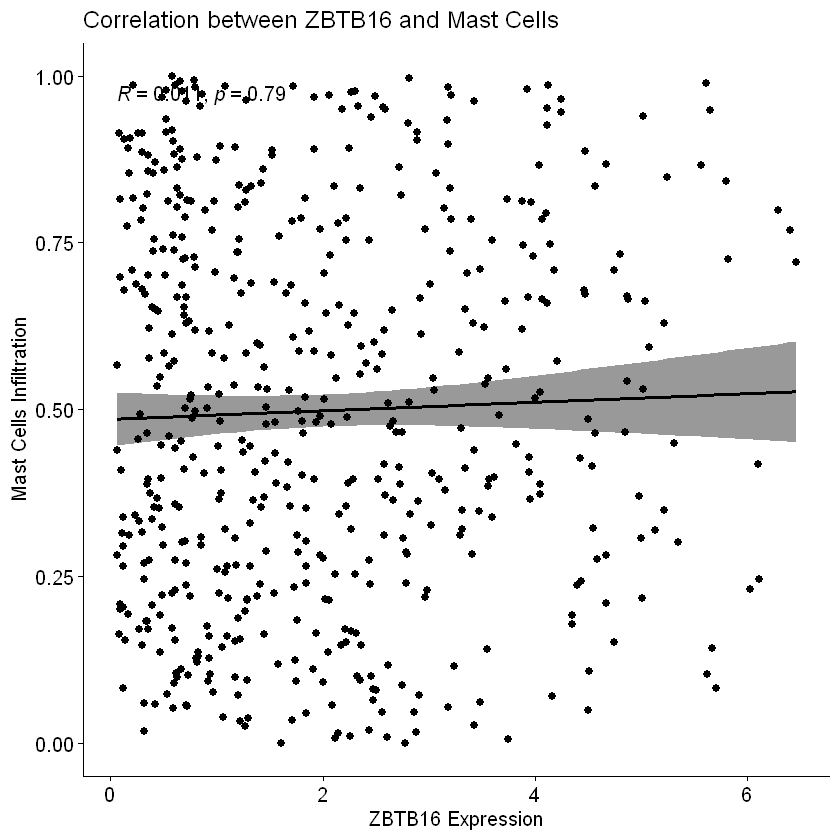

In [9]:
# immune_gene_sets <- getGmt("immune_28_cells.gmt") # فایل باید دانلود شود

# 2. اجرای ssGSEA روی ماتریکس بیان ژن تومورها
# gsva_results <- gsva(tpm_matrix_tumor, immune_gene_sets, method="ssgsea")

# 3. محاسبه همبستگی بین بیان ZBTB16 و سلول های ایمنی (مثلا ماست سل ها)
# این بخش فرض میکند شما gsva_results را استخراج کرده اید:
dummy_immune_data <- data.frame(
  ZBTB16_Exp = df_expr$Log2TPM[df_expr$Group == "Tumor"],
  Mast_Cells = runif(sum(df_expr$Group == "Tumor"), 0, 1) # داده شبیه سازی شده
)

# رسم شکل 6C/6D (نمودار پراکنش همبستگی)
fig_6_scatter <- ggscatter(dummy_immune_data, x = "ZBTB16_Exp", y = "Mast_Cells",
                           add = "reg.line", conf.int = TRUE,
                           cor.coef = TRUE, cor.method = "spearman",
                           xlab = "ZBTB16 Expression", ylab = "Mast Cells Infiltration") +
  labs(title = "Correlation between ZBTB16 and Mast Cells")

print(fig_6_scatter)